# Comparing parallel universes - ecoHeat
When a user has ecoHeat OFF how much could they be saving?
e.g. This is what ecoHeat ON could save you (in a week? day? year?)

In [1]:
# Imports
import ast
import pandas as pd
import requests
from datetime import datetime, timezone, timedelta

from pathlib import Path
from scipy.integrate import trapezoid

from model_helper_functions import get, plot_temp_power

In [2]:
# Set up API call
url = "https://bristol.passivuk.com/optimisation"
with open("API_key.txt", "r") as file:
    API_key = file.read()

#### Research question:
If the user had had ecoHeat enabled - could they have saved money?

In [3]:
# load event files
event_path = Path("data/PSTData5_reformat_v3")
event_files = event_path.glob("*.csv")

houses_events = {}
for file in event_files:
    house_id = file.stem.split("_")[0]
    houses_events[house_id] = pd.read_csv(file)
    houses_events[house_id]["Timestamp"] = pd.to_datetime(houses_events[house_id]["Timestamp"])

In [4]:
temp_path = Path("data/PSTData5")
temp_files = temp_path.glob("*.csv")

houses_temps = {}
for file in temp_files:
    if "Events" not in str(file):
        house_id = file.stem.split("_")[0]
        data = pd.read_csv(file)
        temp = {}
        temp["Datetimes"] = pd.to_datetime(data["Time (UTC)"])
        temp["Setpoint Z1"] = data["Setpoint temperature (Zone 1) (°C)"]
        temp["Room Temp Z1"] = data["Room temperature (Zone 1) (°C)"]
        temp["External Temp"] = data["External temperature (°C)"]
        temp["Input Power Z1"] = data["Power consumption (kW)"]
        temp["Elec Cost (p/kWh)"] = data["Tariff rate (p/kWh)"]
        houses_temps[house_id] = pd.DataFrame(temp)

In [11]:
event_df = houses_events["28679"]
temp_df = houses_temps["28679"]

In [12]:
event_df

,Timestamp,Type,Payload,Override
0,2025-09-30 17:58:22,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'advanc...","{'hours': ['2025-09-30T17:58:22Z'], 'C': [20.0]}"
1,2025-10-01 18:41:29,Schedule,"{'type': 'heating', 'zone': 2, 'mode': 'advanc...","{'hours': ['2025-10-01T18:41:29Z'], 'C': [18.0]}"
2,2025-10-02 06:10:10,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'advanc...","{'hours': ['2025-10-02T06:10:10Z'], 'C': [20.0]}"
3,2025-10-02 07:26:48,Schedule,"{'type': 'heating', 'zone': 2, 'mode': 'advanc...","{'hours': ['2025-10-02T07:26:48Z'], 'C': [18.5]}"
4,2025-10-02 07:27:05,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'advanc...","{'hours': ['2025-10-02T07:27:05Z'], 'C': [19.0]}"
...,...,...,...,...
495,2026-02-28 20:28:01,Schedule,"{'type': 'heating', 'zone': 2, 'mode': 'advanc...",NaN
496,2026-02-28 20:28:09,Schedule,"{'type': 'heating', 'zone': 2, 'mode': 'advanc...",NaN
497,2026-02-28 20:28:18,Schedule,"{'type': 'heating', 'zone': 2, 'mode': 'advanc...",NaN
498,2026-02-28 20:28:25,Schedule,"{'type': 'heating', 'zone': 2, 'mode': 'advanc...",NaN


In [13]:
temp_df

,Datetimes,Setpoint Z1,Room Temp Z1,External Temp,Input Power Z1,Elec Cost (p/kWh)
0,2025-10-01 00:00:00,8.0,20.7,18.0,0.0,NaN
1,2025-10-01 00:05:00,8.0,20.7,18.0,0.0,NaN
2,2025-10-01 00:10:00,8.0,20.7,18.0,0.0,NaN
3,2025-10-01 00:15:00,8.0,20.7,18.0,0.0,NaN
4,2025-10-01 00:20:00,8.0,20.7,18.0,0.0,NaN
...,...,...,...,...,...,...
45788,2026-03-08 23:40:00,8.0,20.5,10.0,0.5,23.83
45789,2026-03-08 23:45:00,8.0,20.5,10.0,0.0,23.83
45790,2026-03-08 23:50:00,8.0,20.5,10.0,0.0,23.83
45791,2026-03-08 23:55:00,8.0,20.5,10.0,0.0,23.83


No output power


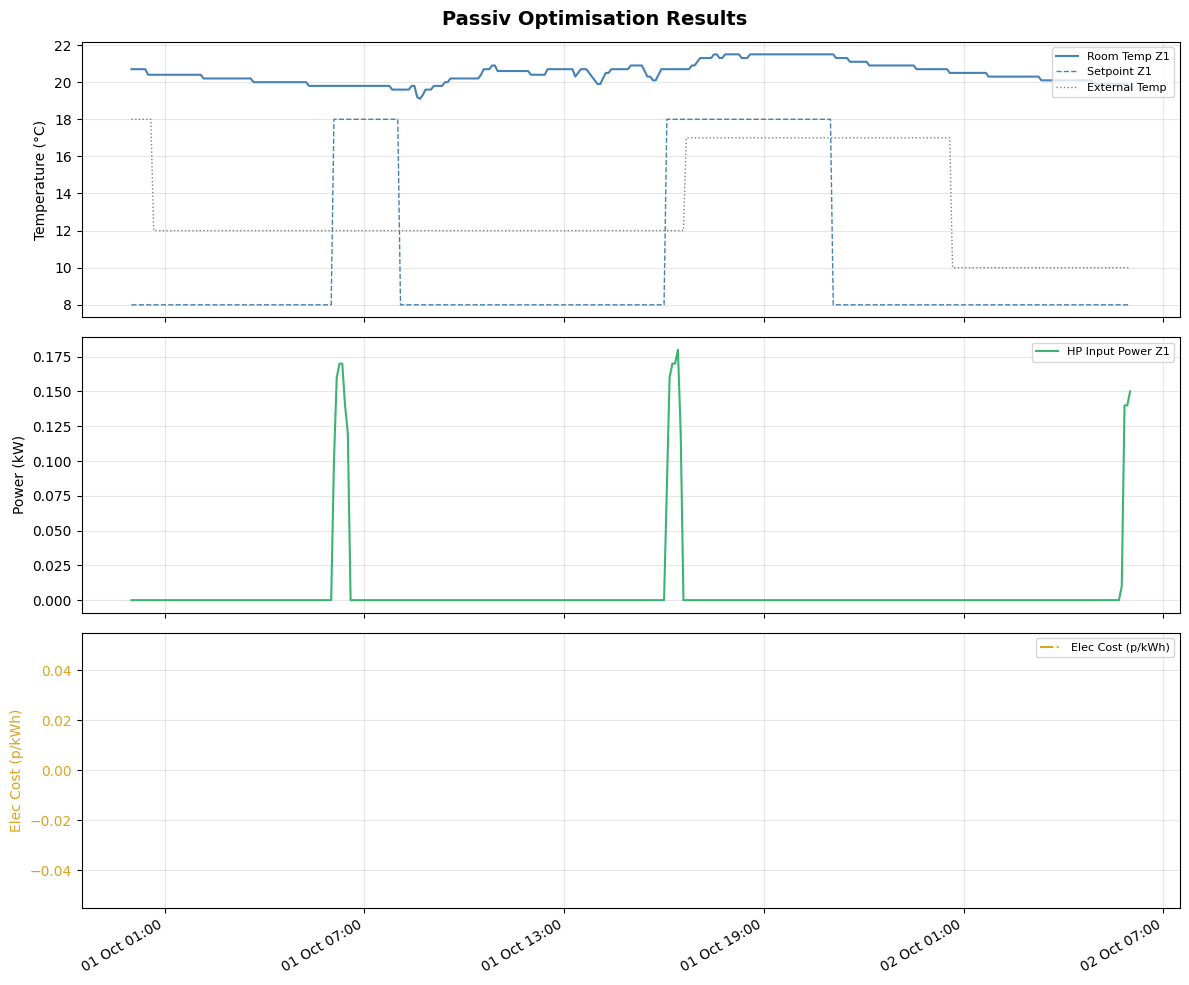

Data covers 30.0 hours (361 timesteps)


In [14]:
plot_temp_power(temp_df.loc[0:30*60/5], 1)

In [ ]:
mask = event_df["Type"] == "Schedule"
schedules = event_df.loc[mask, ["Timestamp", "Payload"]]
schedules

In [ ]:
days_of_week = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

In [ ]:
for i, row in schedules.iterrows():
    time = row.get("Timestamp")
    data = row.get("Payload")
    override = row.get("Override")
    if isinstance(data, str): # if payload is string, convert to dict
        data = ast.literal_eval(data)
    if data.get("type") == "heating" and data.get("mode") == "basic": # only use heating schedules
        # print(time)
        # print(data)
        print(time, data)
        print(days_of_week[time.weekday()])
        print(data["schedule"][days_of_week[time.weekday()]])
        # Next nearest time in dataset
        print(min(
            (d for d in temp_df["Time (UTC)"] if d > time),
            key=lambda d: d - time
        ))
        # print(min(temp_df["Time (UTC)"], key=lambda d: abs(d - time) if d>time))

In [ ]:
# Two schedules to compare
schedule_1_input = {
"num_zones": 1,
"zone_1_heating_daily_schedule": {"hours": [8, 10, 14, 16], "C": [21, 'frost', 21, 'frost']},
"start_datetime": "2024-01-01T07:00:00Z",
# "zone_1_temperature": 19 <- default
}

schedule_2_input = {
"num_zones": 1,
"zone_1_heating_daily_schedule": {"hours": [8, 10, 14, 16], "C": [20, 'frost', 20, 'frost']},
"start_datetime": "2024-01-01T07:00:00Z",
# "zone_1_temperature": 19 <- default
}

In [ ]:
return_1 = requests.post(url, headers={"X-API-Key": API_key}, json=schedule_1_input).json()
return_2 = requests.post(url, headers={"X-API-Key": API_key}, json=schedule_2_input).json()

### Plot results

In [ ]:
output_data = []
for outputs in [return_1, return_2]:
    if outputs['success']:
        dts = [datetime.fromisoformat(t.replace("Z", "+00:00")) for t in outputs["real_dt"]]
        n = len(dts)
        S = outputs["State"]
        df = pd.DataFrame({
            "Datetimes": dts,
            "Setpoint Z1": get(S, n, "setpoint.z1"),
            "Room Temp Z1": get(S, n, "room_temp.z1"),
            "External Temp": get(S, n, "ext"),
            "Input Power Z1": get(S, n, "E.hs1.heat.z1"),
            "Output Power Z1": get(S, n, "U.hs1.z1"),
            "Elec Cost (p/kWh)": get(S, n, "elec_cost"),
            "Tank Temp": get(S, n, "tank_temp"),
            "HW Setpoint": get(S, n, "setpoint_hw")
            # "Tariff":get(S, n, "tariff")
        })
        output_data.append(df)
        plot_temp_power(df, schedule_1_input.get("num_zones"))

### Calculate energy costs

In [ ]:
def get_time_passed(df, start_time=datetime(year=2024, month=1, day=1, hour=0)):
    time_in_hours = []
    start_time = start_time.replace(tzinfo=timezone(timedelta(hours=0, minutes=0)))
    for time in df.Datetimes:
        time_elapsed = time-start_time  # Time deltas store time in days and seconds (for reasons....)
        time_in_hours.append(time_elapsed.days*24 + time_elapsed.seconds/(60*60))  # Time in hours since the start!
    return time_in_hours

In [ ]:
for df in output_data:
        print("Total power used: ", round(sum(df["Output Power Z1"].dropna()), 2), " kW")
        power_df = df.copy(deep=True).dropna()
        time_in_hours = get_time_passed(power_df)
        if len(set(power_df["Elec Cost (p/kWh)"])) == 1:
                energy_used = trapezoid(power_df["Input Power Z1"], x=time_in_hours)
                print("Total energy used: ", round(energy_used, 2), " kWh")
                print("Energy cost: £", round(energy_used*df["Elec Cost (p/kWh)"][1]/100, 2))
        
        # else:
        #       need to go through dataframe
        #       integrate curve between times where energy cost values change
        #       calculate energy for each tariff + therefore cost for each chunk
        #       sum up to get total
